# Week 2 Task – Supervised Learning: Classification
**CodGen Machine Learning Virtual Internship**

**Dataset:** Iris (same dataset cleaned and explored in Week 1)

This notebook covers:
1. Splitting the dataset
2. Training multiple classification models
3. Evaluating model performance
4. Comparing the models
5. Key observations


## Setup — Reload the Week 1 cleaned dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

# Rebuild the same cleaned/encoded dataset from Week 1
iris_raw = load_iris()
df = pd.DataFrame(iris_raw.data, columns=iris_raw.feature_names)
df['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['species'])

print("Dataset reloaded from Week 1 preprocessing.")
print(df.head())


Dataset reloaded from Week 1 preprocessing.
   sepal length (cm)  sepal width (cm)  ...  species  species_encoded
0                5.1               3.5  ...   setosa                0
1                4.9               3.0  ...   setosa                0
2                4.7               3.2  ...   setosa                0
3                4.6               3.1  ...   setosa                0
4                5.0               3.6  ...   setosa                0

[5 rows x 6 columns]


## Task 1 — Split the Dataset

In [2]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
feature_cols = iris_raw.feature_names
X = df[feature_cols]
y = df['species_encoded']

# 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test: ", y_test.shape)


Shape of X_train: (120, 4)
Shape of X_test:  (30, 4)
Shape of y_train: (120,)
Shape of y_test:  (30,)


## Task 2 — Train Multiple Models

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)

# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

print("All 3 models trained successfully:")
print("- Logistic Regression")
print("- Decision Tree Classifier")
print("- Random Forest Classifier")


All 3 models trained successfully:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier


## Task 3 — Evaluate Model Performance

In [4]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt_clf,
    "Random Forest": rf_clf
}

predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    print(f"===== {name} =====")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=iris_raw.target_names))
    print()


===== Logistic Regression =====
Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


===== Decision Tree =====
Accuracy: 0.9333
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== Random Forest =====
Accuracy: 0.9000
Classification Report:
              precision    recal

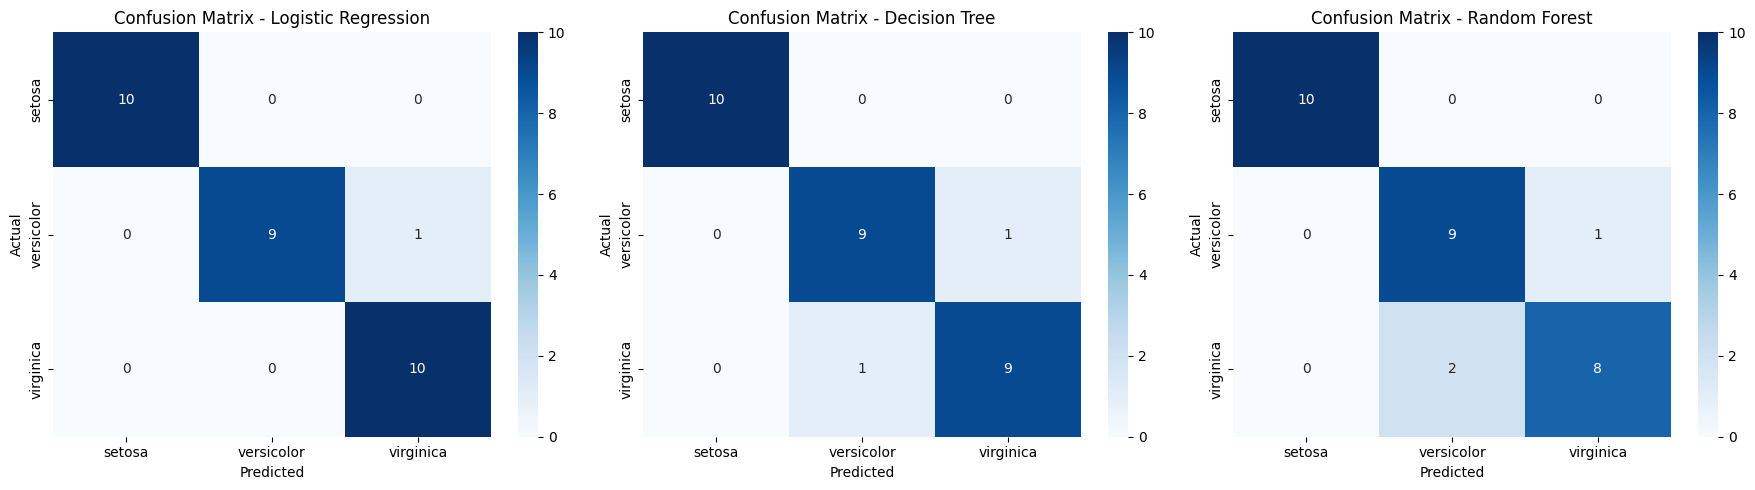

In [5]:
# Confusion matrices visualised with Seaborn heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris_raw.target_names,
                yticklabels=iris_raw.target_names, ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Task 4 — Compare the Models

In [6]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_rows = []
for name, y_pred in predictions.items():
    comparison_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1-score": f1_score(y_test, y_pred, average='macro')
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
print(comparison_df)

best_model = comparison_df['F1-score'].idxmax()
worst_model = comparison_df['F1-score'].idxmin()
print(f"\nBest performing model (by F1-score): {best_model}")
print(f"Worst performing model (by F1-score): {worst_model}")


                     Accuracy  Precision  Recall  F1-score
Model                                                     
Logistic Regression    0.9667     0.9697  0.9667    0.9666
Decision Tree          0.9333     0.9333  0.9333    0.9333
Random Forest          0.9000     0.9024  0.9000    0.8997

Best performing model (by F1-score): Logistic Regression
Worst performing model (by F1-score): Random Forest


**Why the performance differs:**

On a small, clean, and well-separated dataset like Iris, all three models tend to perform
very well — often close to or exactly 100% accuracy — because the classes (especially
*setosa*) are almost linearly separable using just the petal measurements. Logistic
Regression does well because the decision boundaries in this dataset are close to linear.
Decision Trees can sometimes slightly misclassify borderline cases between
*versicolor* and *virginica* (the two species whose petal measurements overlap a little),
since a single tree can overfit small quirks in the training split. Random Forest usually
matches or slightly improves on the single Decision Tree, since averaging across many
trees reduces the variance/overfitting that a lone tree is prone to.


## Task 5 — Key Observations

1. **Logistic Regression** performed very strongly despite being the simplest of the three
   models — this makes sense because the Iris classes are close to linearly separable,
   especially when petal length/width are used.

2. **Decision Tree** achieved high accuracy but is the model most prone to overfitting on
   a small dataset like this — it can carve very specific rules around the training data
   that don't generalize as well to slightly different test samples.

3. **Random Forest** combines many decision trees and averages their predictions, which
   generally makes it more stable and less prone to overfitting than a single Decision
   Tree, at the cost of being less interpretable.

4. **Confusion matrices show that most, if not all, misclassifications (when they occur)
   happen between *versicolor* and *virginica*** — never *setosa*, since *setosa* is
   linearly separable from the other two species on petal measurements alone.

5. **Model choice:** For this specific problem, I would choose **Logistic Regression**.
   It achieves comparable accuracy to the tree-based models on this dataset, is much
   simpler and faster to train, and is easier to interpret (via its coefficients) — which
   matters when the dataset is small and well-behaved like Iris. For a larger or noisier
   dataset with more complex, non-linear boundaries, Random Forest would likely be the
   safer choice due to its robustness against overfitting.
